# **Water Quality Data Analysis**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [35]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\DA2_Assessment'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [36]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [37]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project'

# Section 1

Section 1 content

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv("DA2_Assessment/Data/Raw_data/healthcare-dataset-stroke-data.csv")
df.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [42]:
list(df.columns)

['id',
 'gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'avg_glucose_level',
 'bmi',
 'smoking_status',
 'stroke']

In [43]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


(5110, 12)

In [44]:
df.duplicated().sum()

0

In [45]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


---

# Section 2: Transform

**Missing Values Analysis**

In [46]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [47]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)

In [48]:
df['bmi'].isnull().sum()

0

**Outlier Detection**

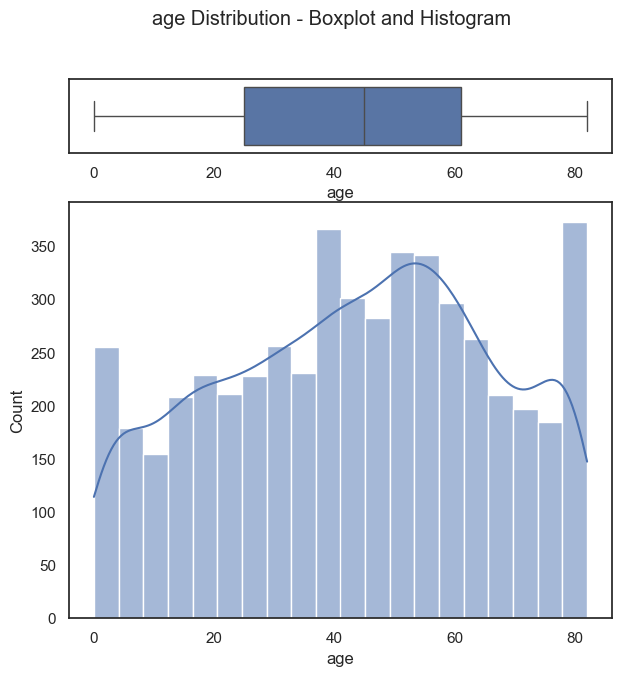

This is the range where a data point is not an outlier: from -29.0 to 115.0




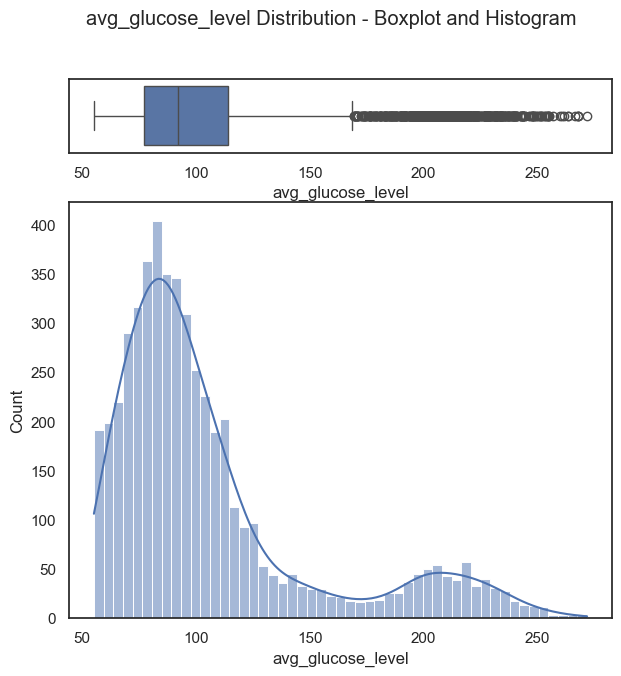

This is the range where a data point is not an outlier: from 21.98 to 169.36




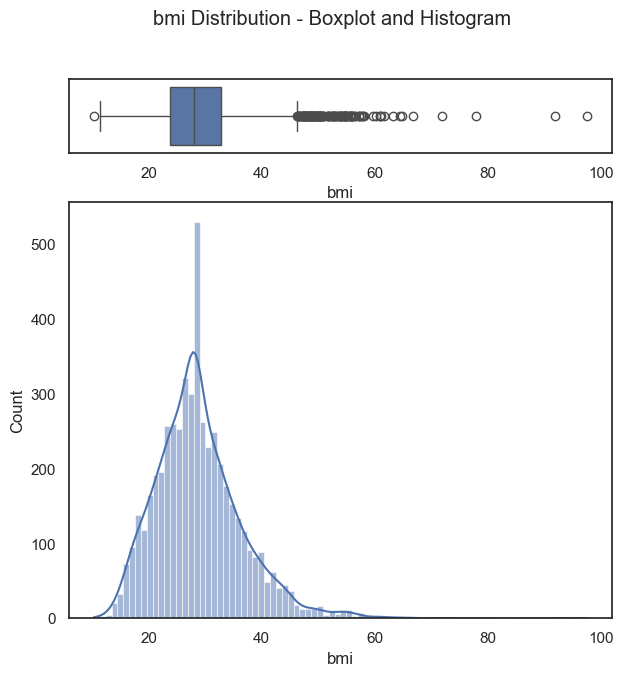

This is the range where a data point is not an outlier: from 10.3 to 46.3




In [52]:
def plot_histogram_and_boxplot(df):
    selected_cols = ['age', 'avg_glucose_level', 'bmi']
    
    for col in selected_cols:
        fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 7), gridspec_kw={"height_ratios": (.15, .85)})
        sns.boxplot(data=df, x=col, ax=axes[0])
        sns.histplot(data=df, x=col, kde=True, ax=axes[1])
        fig.suptitle(f"{col} Distribution - Boxplot and Histogram")
        plt.show()

        # Only calculate IQR for numeric columns
        if pd.api.types.is_numeric_dtype(df[col]):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = (Q1 - 1.5 * IQR).round(2)
            upper = (Q3 + 1.5 * IQR).round(2)
            print(f"This is the range where a data point is not an outlier: from {lower} to {upper}")
            print("\n")
plot_histogram_and_boxplot(df)

**Winsorizer - Capping Outliers**

---

In [61]:
from feature_engine.outliers import Winsorizer
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('winsorizer_iqr', Winsorizer(capping_method = 'iqr', fold=1.5, tail='both', variables = ['bmi','avg_glucose_level']))
])
df_transformed = pipeline.fit_transform(df)
df_transformed.head(8)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,169.3575,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,169.3575,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.9200,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,169.3575,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,169.3575,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,169.3575,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.0900,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.3900,22.8,never smoked,1


In [62]:
pipeline['winsorizer_iqr'].right_tail_caps_

{'bmi': 46.29999999999999, 'avg_glucose_level': 169.35750000000002}

In [63]:
pipeline['winsorizer_iqr'].left_tail_caps_

{'bmi': 10.300000000000006, 'avg_glucose_level': 21.977500000000006}

========Before Outlier Treatment========


========Before Outlier Treatment========


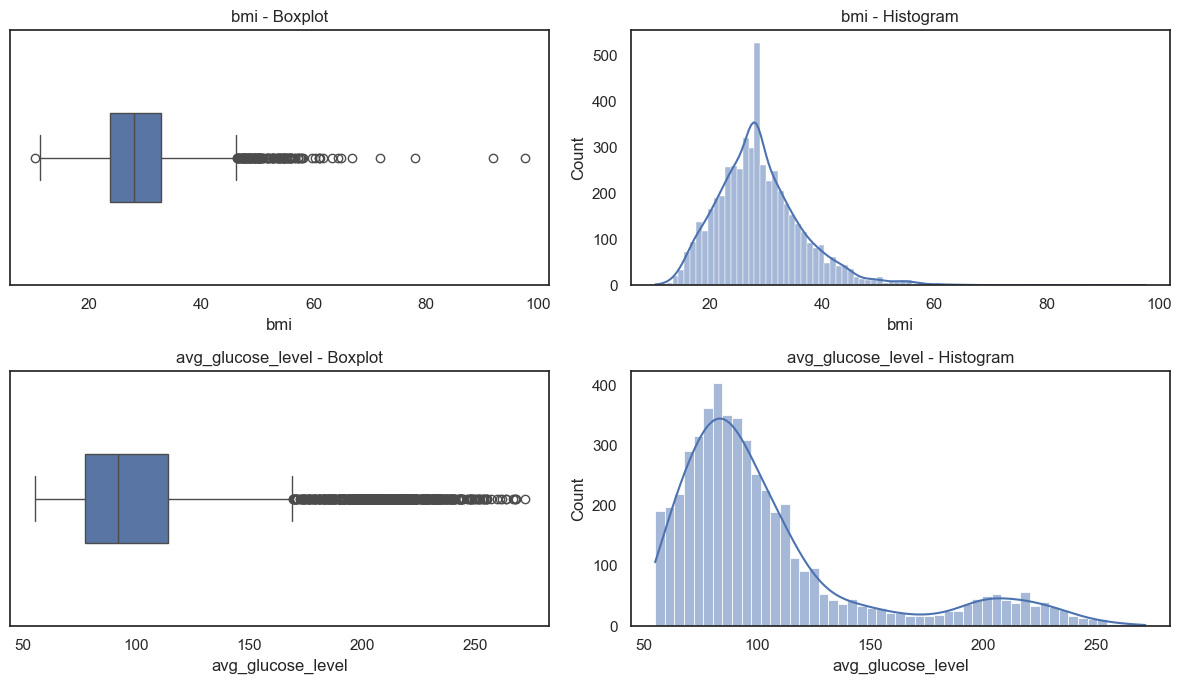

========Before Outlier Treatment========


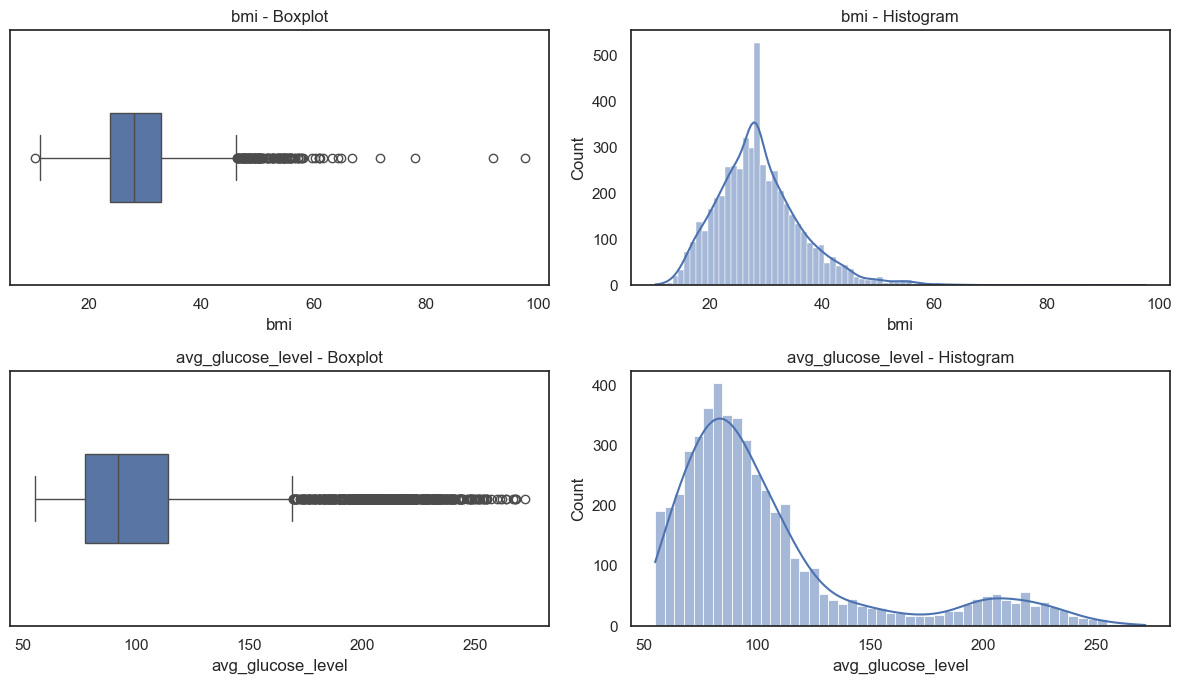

========After Outlier Treatment========


========Before Outlier Treatment========


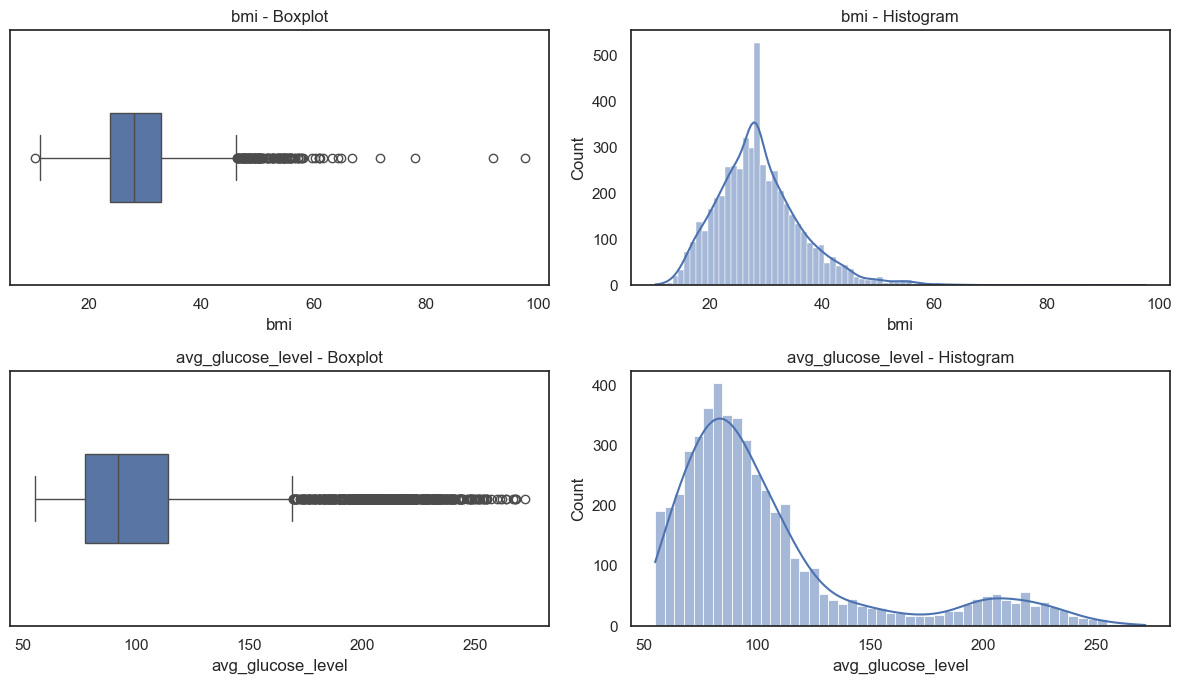

========After Outlier Treatment========


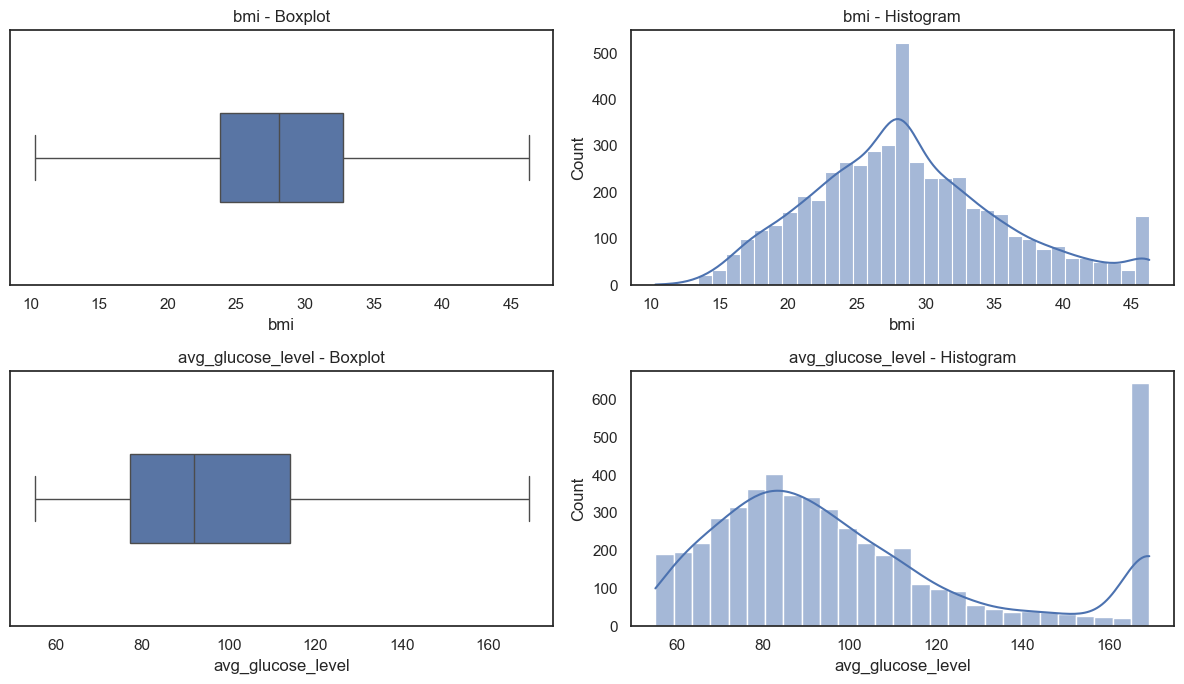

In [70]:
print("========Before Outlier Treatment========")
selected_cols = ['bmi', 'avg_glucose_level']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

for idx, col in enumerate(selected_cols):
    box_ax = axes[idx, 0]
    hist_ax = axes[idx, 1]
    sns.boxplot(data=df, x=col, ax=box_ax, width=0.35)
    sns.histplot(data=df, x=col, kde=True, ax=hist_ax)
    box_ax.set_title(f"{col} - Boxplot")
    hist_ax.set_title(f"{col} - Histogram")

plt.tight_layout()
plt.show()


print("========After Outlier Treatment========")
selected_cols = ['bmi', 'avg_glucose_level']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

for idx, col in enumerate(selected_cols):
    box_ax = axes[idx, 0]
    hist_ax = axes[idx, 1]
    sns.boxplot(data=df_transformed, x=col, ax=box_ax, width=0.35)
    sns.histplot(data=df_transformed, x=col, kde=True, ax=hist_ax)
    box_ax.set_title(f"{col} - Boxplot")
    hist_ax.set_title(f"{col} - Histogram")

plt.tight_layout()
plt.show()

In [75]:
df_transformed.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,100.996204,28.690411,0.048728
std,21161.721625,22.612647,0.296607,0.226063,33.214738,7.120858,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,169.357500,46.300000,1.000000


In [ ]:
*OneHo#~## tEncoder ##

In [ ]:
from feature_engine.encoding import OneHotEncoder

In order to know which variable to apply the OneHotEncoder Ordinal Enconder each catergorical variable's unique values need to be know 

In [90]:
df_transformed['Residence_type'].unique()

array(['Urban', 'Rural'], dtype=object)

In [91]:
df_transformed['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [92]:
df_transformed['smoking_status'].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [ ]:
# One-hot encode the 'sex' and 'smoker' columns while keeping the original categorical data.
# This allows us to use the encoded columns for modelling without losing the original labels for interpretation or categorical data visualization.

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')

encoded = ohe.fit_transform(df_transformed[['gender','ever_married','Residence_type']])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['gender', 'ever_married','Residence_type']))

df_final = pd.concat([df_transformed, encoded_df], axis=1)
df_final.head(8)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Male,gender_Other,ever_married_Yes,Residence_type_Urban
0,9046,Male,67.0,0,1,Yes,Private,Urban,169.3575,36.6,formerly smoked,1,1.0,0.0,1.0,1.0
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,169.3575,28.1,never smoked,1,0.0,0.0,1.0,0.0
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.9200,32.5,never smoked,1,1.0,0.0,1.0,0.0
3,60182,Female,49.0,0,0,Yes,Private,Urban,169.3575,34.4,smokes,1,0.0,0.0,1.0,1.0
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,169.3575,24.0,never smoked,1,0.0,0.0,1.0,0.0
5,56669,Male,81.0,0,0,Yes,Private,Urban,169.3575,29.0,formerly smoked,1,1.0,0.0,1.0,1.0
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.0900,27.4,never smoked,1,1.0,0.0,1.0,0.0
7,10434,Female,69.0,0,0,No,Private,Urban,94.3900,22.8,never smoked,1,0.0,0.0,0.0,1.0


In [95]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()

encoded = oe.fit_transform(df[['work_type', 'smoking_status']])
encoded_df = pd.DataFrame(encoded, columns=['work_type_encoded', 'smoking_status_encoded'], index=df.index)

df_final = df_final.join(encoded_df)
df_final.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Male,gender_Other,ever_married_Yes,Residence_type_Urban,work_type_encoded,smoking_status_encoded
0,9046,Male,67.0,0,1,Yes,Private,Urban,169.3575,36.6,formerly smoked,1,1.0,0.0,1.0,1.0,2.0,1.0
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,169.3575,28.1,never smoked,1,0.0,0.0,1.0,0.0,3.0,2.0
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.9200,32.5,never smoked,1,1.0,0.0,1.0,0.0,2.0,2.0
3,60182,Female,49.0,0,0,Yes,Private,Urban,169.3575,34.4,smokes,1,0.0,0.0,1.0,1.0,2.0,3.0
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,169.3575,24.0,never smoked,1,0.0,0.0,1.0,0.0,3.0,2.0


NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.